Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Load Dataset

In [4]:
df = pd.read_csv(r"C:\Users\HP\Downloads\diabetes (1).csv")

print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())

First 5 rows:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1 

Data Visualization
    Outcome Distribution

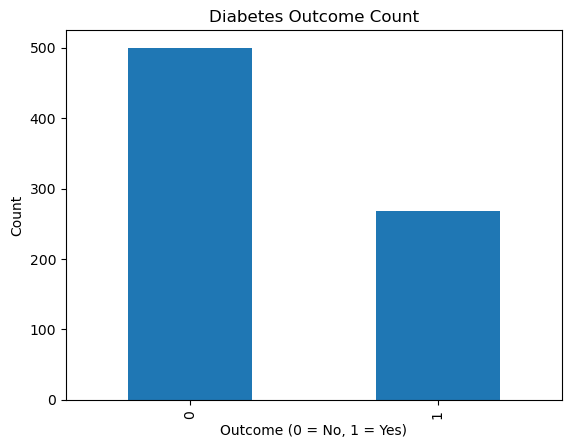

In [7]:
df['Outcome'].value_counts().plot(kind='bar')
plt.title("Diabetes Outcome Count")
plt.xlabel("Outcome (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

Feature Distribution

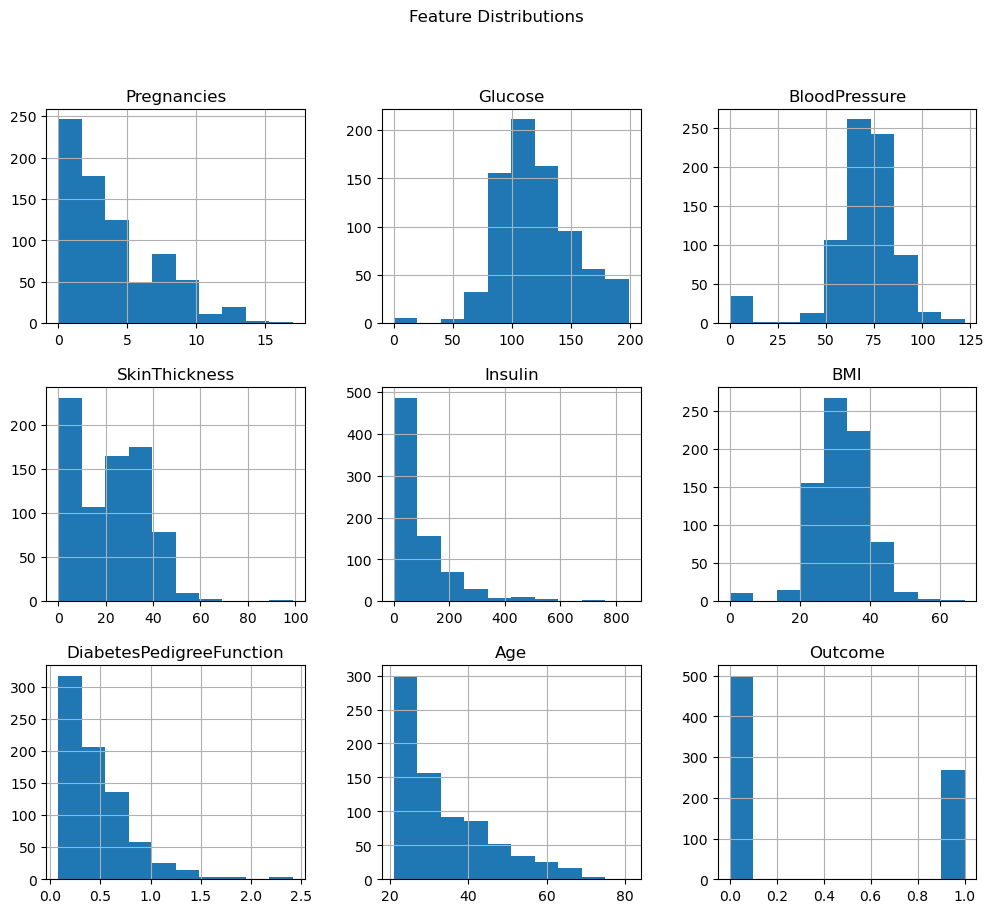

In [9]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

Correlation Heatmap

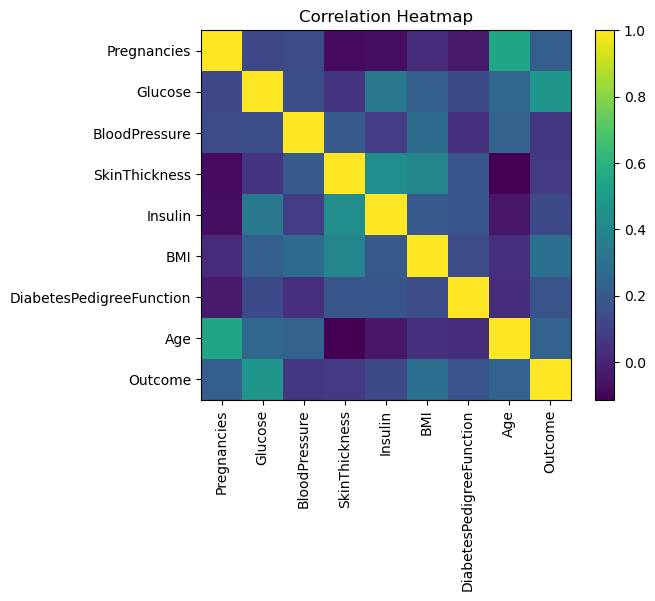

In [10]:
corr = df.corr()

plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

Data Preprocessing

In [ ]:

X = df.drop("Outcome", axis=1)
y = df["Outcome"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Logistic Regression Model

In [12]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("\n===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))


===== Logistic Regression =====
Accuracy: 0.7532467532467533
[[79 20]
 [18 37]]
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



Decision Tree Model

In [17]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("\n===== Decision Tree =====")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))


===== Decision Tree =====
Accuracy: 0.7467532467532467
[[75 24]
 [15 40]]
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



KNN Model

In [19]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("\n===== KNN =====")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print(confusion_matrix(y_test, knn_pred))
print(classification_report(y_test, knn_pred))


===== KNN =====
Accuracy: 0.6948051948051948
[[79 20]
 [27 28]]
              precision    recall  f1-score   support

           0       0.75      0.80      0.77        99
           1       0.58      0.51      0.54        55

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.66       154
weighted avg       0.69      0.69      0.69       154



Confusion Matrix Visualization

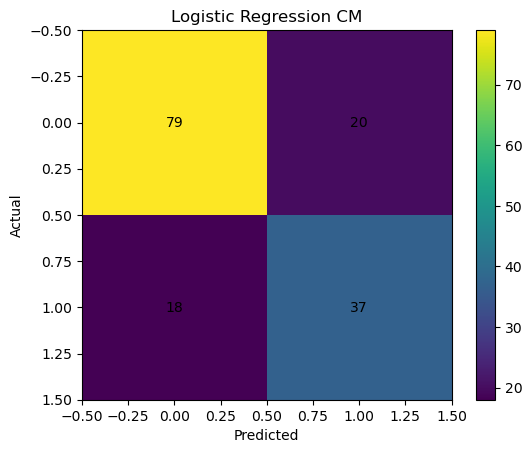

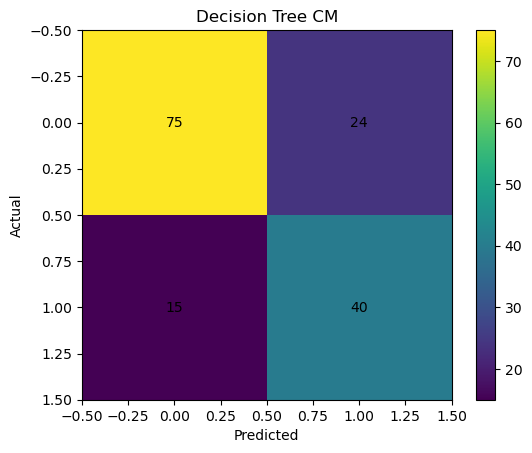

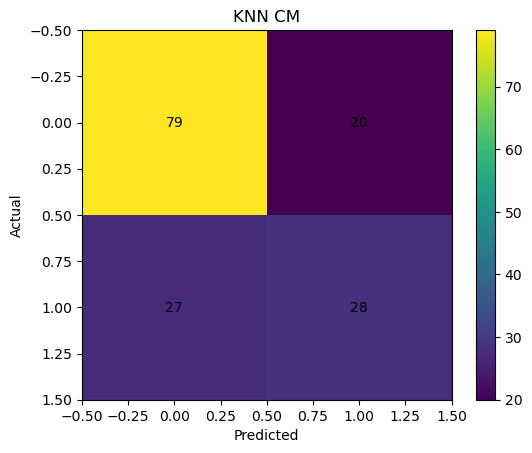

In [21]:
def plot_confusion(cm, title):
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(len(cm)):
        for j in range(len(cm)):
            plt.text(j, i, cm[i][j], ha='center', va='center')

    plt.show()

plot_confusion(confusion_matrix(y_test, lr_pred), "Logistic Regression CM")
plot_confusion(confusion_matrix(y_test, dt_pred), "Decision Tree CM")
plot_confusion(confusion_matrix(y_test, knn_pred), "KNN CM")

Model Comparison Plot

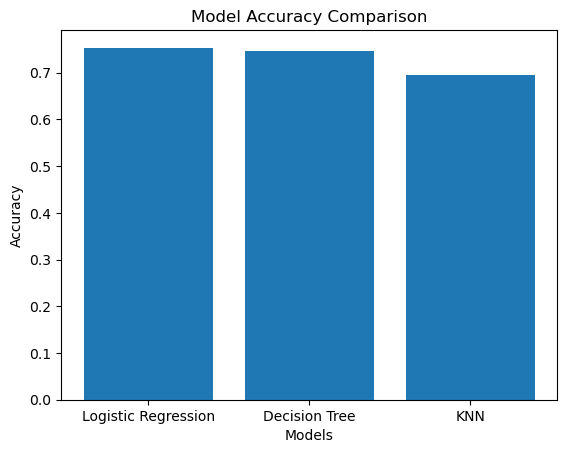

In [23]:
lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
knn_acc = accuracy_score(y_test, knn_pred)

models = ['Logistic Regression', 'Decision Tree', 'KNN']
accuracies = [lr_acc, dt_acc, knn_acc]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

KNN Hyperparameter (K Value Analysis)

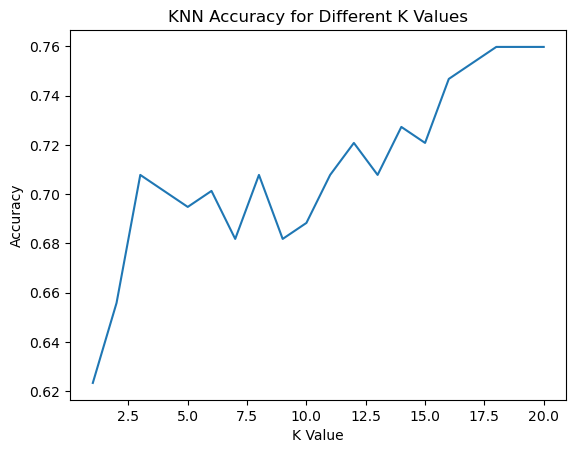

In [25]:
k_values = range(1, 21)
knn_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    knn_scores.append(accuracy_score(y_test, pred))

plt.plot(k_values, knn_scores)
plt.title("KNN Accuracy for Different K Values")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.show()

Prediction on New Data

In [27]:
sample = pd.DataFrame([[6,148,72,35,0,33.6,0.627,50]], 
                      columns=X.columns)

sample = scaler.transform(sample)

print("\nPrediction:")
print("Logistic Regression:", lr_model.predict(sample))
print("Decision Tree:", dt_model.predict(sample))
print("KNN:", knn_model.predict(sample))


Prediction:
Logistic Regression: [1]
Decision Tree: [1]
KNN: [1]


User Input

In [31]:
print("\nEnter Patient Details:")

glucose = float(input("Glucose: "))
bmi = float(input("BMI: "))
age = int(input("Age: "))


mean_values = X.mean()

user_data = mean_values.copy()

user_data['Glucose'] = glucose
user_data['BMI'] = bmi
user_data['Age'] = age


user_data = pd.DataFrame([user_data])

user_data = scaler.transform(user_data)

result = lr_model.predict(user_data)[0]

print("\nPrediction:", "Diabetic" if result == 1 else "Not Diabetic")


Enter Patient Details:


Glucose:  12
BMI:  12
Age:  12



Prediction: Not Diabetic
